## задание 1 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import precision_score
from catboost import CatBoostClassifier
import numpy as np
from sentence_transformers import SentenceTransformer, util
import requests

pd.set_option('display.max_columns', 100)

ratings = pd.read_csv('ratings.csv')
ratings

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3
...,...,...,...
5976474,49925,510,5
5976475,49925,528,4
5976476,49925,722,4
5976477,49925,949,5


Count of unique users: 53424
Count of unique books: 10000


,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,The Great Gatsby,eng,3.89,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...
5,6,11870085,11870085,16827462,226,525478817,9.780525e+12,John Green,2012.0,The Fault in Our Stars,The Fault in Our Stars,eng,4.26,2346404,2478609,140739,47994,92723,327550,698471,1311871,https://images.gr-assets.com/books/1360206420m...,https://images.gr-assets.com/books/1360206420s...
6,7,5907,5907,1540236,969,618260307,9.780618e+12,J.R.R. Tolkien,1937.0,The Hobbit or There and Back Again,The Hobbit,en-US,4.25,2071616,2196809,37653,46023,76784,288649,665635,1119718,https://images.gr-assets.com/books/1372847500m...,https://images.gr-assets.com/books/1372847500s...
7,8,5107,5107,3036731,360,316769177,9.780317e+12,J.D. Salinger,1951.0,The Catcher in the Rye,The Catcher in the Rye,eng,3.79,2044241,2120637,44920,109383,185520,455042,661516,709176,https://images.gr-assets.com/books/1398034300m...,https://images.gr-assets.com/books/1398034300s...
8,9,960,960,3338963,311,1416524797,9.781417e+12,Dan Brown,2000.0,Angels & Demons,"Angels & Demons (Robert Langdon, #1)",en-CA,3.85,2001311,2078754,25112,77841,145740,458429,716569,680175,https://images.gr-assets.com/books/1303390735m...,https://images.gr-assets.com/books/1303390735s...
9,10,1885,1885,3060926,3455,679783261,9.780680e+12,Jane Austen,1813.0,Pride and Prejudice,Pride and Prejudice,eng,4.24,2035490,2191465,49152,54700,86485,284852,609755,1155673,https://images.gr-assets.com/books/1320399351m...,https://images.gr-assets.com/books/1320399351s...


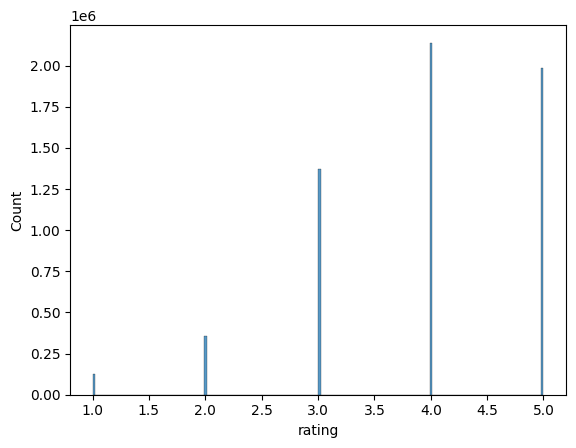

In [3]:
print(f'Count of unique users: {ratings.user_id.nunique()}')
print(f'Count of unique books: {ratings.book_id.nunique()}')

ratings[ratings.user_id==258]

sns.histplot(ratings.rating)

from sklearn.model_selection import train_test_split
train_df, test_df, train_y, test_y = train_test_split(ratings[['user_id', 'book_id']], ratings.rating, train_size=0.8)

books = pd.read_csv('books.csv')

books.head(10)

In [4]:
list(books)

genres_df = pd.read_json('goodreads_book_genres_initial.json', lines=True)

genres_df = genres_df[genres_df.book_id.isin(books.goodreads_book_id)]

genres_df.columns = ['book_id', 'genres_dict']

genres_df.head(5)

,book_id,genres_dict
3,6066819,"{'fiction': 555, 'romance': 23, 'mystery, thri..."
15,89375,"{'non-fiction': 534, 'history, historical fict..."
583,54270,"{'history, historical fiction, biography': 108..."
807,38568,"{'fantasy, paranormal': 1907, 'romance': 1598,..."
816,38562,"{'fantasy, paranormal': 1002, 'romance': 896, ..."


In [5]:
all_genres = set()
for dict_genre in genres_df.genres_dict:
    for elem in list(dict_genre.keys()):
        all_genres.add(elem)

all_genres

for genre in all_genres:
    genres_df[genre] = 0

def simple_one_hot(genre_dict, genre):
    if genre in genre_dict:
        return 1
    return 0

for genre in all_genres:
    genres_df[genre] = genres_df.apply(lambda df: simple_one_hot(df['genres_dict'], genre), axis=1)

genres_df

,book_id,genres_dict,children,young-adult,"mystery, thriller, crime",poetry,"fantasy, paranormal","history, historical fiction, biography",fiction,non-fiction,"comics, graphic",romance
3,6066819,"{'fiction': 555, 'romance': 23, 'mystery, thri...",0,0,1,0,0,0,1,0,0,1
15,89375,"{'non-fiction': 534, 'history, historical fict...",0,0,0,0,0,1,1,1,1,0
583,54270,"{'history, historical fiction, biography': 108...",0,0,0,0,0,1,0,1,1,0
807,38568,"{'fantasy, paranormal': 1907, 'romance': 1598,...",0,0,0,0,1,0,1,0,0,1
816,38562,"{'fantasy, paranormal': 1002, 'romance': 896, ...",0,0,1,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2359417,7663,"{'fiction': 409, 'mystery, thriller, crime': 4...",0,0,1,0,0,0,1,1,0,0
2359672,6280379,"{'fiction': 1254, 'history, historical fiction...",0,0,0,0,1,1,1,0,0,0
2360252,6871646,"{'children': 1036, 'fiction': 57, 'fantasy, pa...",1,0,0,1,1,0,1,0,0,0
2360258,7657484,"{'comics, graphic': 1535, 'fiction': 70, 'fant...",0,1,0,0,1,1,1,0,1,0


In [6]:
train_df = train_df.merge(books[['book_id', 'goodreads_book_id']], left_on='book_id', right_on='book_id', how='left')
test_df = test_df.merge(books[['book_id', 'goodreads_book_id']], left_on='book_id', right_on='book_id', how='left')

train_df = train_df.merge(genres_df, left_on='goodreads_book_id', right_on='book_id', how='left')
test_df = test_df.merge(genres_df, left_on='goodreads_book_id', right_on='book_id', how='left')

train_df.head(5)

,user_id,book_id_x,goodreads_book_id,book_id_y,genres_dict,children,young-adult,"mystery, thriller, crime",poetry,"fantasy, paranormal","history, historical fiction, biography",fiction,non-fiction,"comics, graphic",romance
0,19950,5896,12881141,12881141.0,"{'romance': 1193, 'fiction': 49, 'mystery, thr...",0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,34253,91,6186357,6186357.0,"{'young-adult': 10128, 'fiction': 6972, 'fanta...",0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,40289,2454,1314332,1314332.0,"{'romance': 340, 'fiction': 537, 'young-adult'...",0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,43417,1549,324277,324277.0,"{'fiction': 1045, 'young-adult': 756, 'childre...",1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,4715,1324,781110,781110.0,"{'fiction': 3274, 'history, historical fiction...",1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [7]:
users_profiles = train_df.groupby('user_id')[list(all_genres)].sum()

users_profiles.columns = ['user_'+name for name in list(users_profiles)]

users_profiles

,user_children,user_young-adult,"user_mystery, thriller, crime",user_poetry,"user_fantasy, paranormal","user_history, historical fiction, biography",user_fiction,user_non-fiction,"user_comics, graphic",user_romance
user_id,,,,,,,,,,
1,5.0,37.0,27.0,2.0,23.0,72.0,91.0,19.0,9.0,41.0
2,11.0,17.0,9.0,3.0,11.0,22.0,34.0,30.0,7.0,15.0
3,9.0,21.0,17.0,10.0,23.0,51.0,64.0,18.0,8.0,14.0
4,28.0,60.0,36.0,4.0,48.0,61.0,106.0,20.0,7.0,26.0
5,9.0,16.0,64.0,1.0,27.0,20.0,79.0,2.0,3.0,22.0
...,...,...,...,...,...,...,...,...,...,...
53420,16.0,54.0,35.0,1.0,42.0,33.0,84.0,10.0,6.0,51.0
53421,13.0,34.0,36.0,2.0,54.0,66.0,94.0,29.0,9.0,29.0
53422,17.0,66.0,52.0,6.0,87.0,34.0,97.0,10.0,20.0,44.0


In [8]:
train_df = train_df.merge(users_profiles, left_on='user_id', right_on='user_id', how='left')
test_df = test_df.merge(users_profiles, left_on='user_id', right_on='user_id', how='left')

In [9]:
books = books.merge(genres_df, left_on='goodreads_book_id', right_on='book_id', how='left')
books.columns = ['book_'+item if item in all_genres else item for item in list(books)]
books

,book_id_x,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url,book_id_y,genres_dict,book_children,book_young-adult,"book_mystery, thriller, crime",book_poetry,"book_fantasy, paranormal","book_history, historical fiction, biography",book_fiction,book_non-fiction,"book_comics, graphic",book_romance
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,2767052.0,"{'young-adult': 30173, 'fiction': 26304, 'fant...",0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,3.0,"{'fantasy, paranormal': 54156, 'young-adult': ...",1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...,41865.0,"{'young-adult': 19627, 'fantasy, paranormal': ...",0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...,2657.0,"{'fiction': 8870, 'history, historical fiction...",0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,The Great Gatsby,eng,3.89,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...,4671.0,"{'fiction': 20684, 'history, historical fictio...",0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7130616,7130616,7392860,19,441019455,9.780441e+12,Ilona Andrews,2010.0,Bayou Moon,"Bayou Moon (The Edge, #2)",eng,4.09,17204,18856,1180,105,575,3538,7860,6778,https://images.gr-assets.com/books/1307445460m...,https://images.gr-assets.com/books/1307445460s...,7130616.0,"{'fantasy, paranormal': 2872, 'romance': 913, ...",0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
9996,9997,208324,208324,1084709,19,067973371X,9.780680e+12,Robert A. Caro,1990.0,Means of Ascent,"Means of Ascent (The Years of Lyndon Johnson, #2)",eng,4.25,12582,12952,395,303,551,1737,3389,6972,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...,208324.0,"{'history, historical fiction, biography': 775...",0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
9997,9998,77431,77431,2393986,60,039330762X,9.780393e+12,Patrick O'Brian,1977.0,The Mauritius Command,The Mauritius Command,eng,4.35,9421,10733,374,11,111,1191,4240,5180,https://images.gr-assets.com/books/1455373531m...,https://images.gr-assets.com/books/1455373531s...,77431.0,"{'fiction': 991, 'history, historical fiction,...",0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
9998,9999,8565083,8565083,13433613,7,61711527,9.780062e+12,Peggy Orenstein,2011.0,Cinderella Ate My Daughter: Dispatches from th...,Cinderella Ate My Daughter: Dispatches from th...,eng,3.65,11279,11994,1988,275,1002,3765

In [7]:
train_df.columns = ['book_'+item if item in all_genres else item for item in list(train_df)]
test_df.columns = ['book_'+item if item in all_genres else item for item in list(test_df)]

train_df

,user_id,book_id_x,goodreads_book_id,book_id_y,genres_dict,book_young-adult,"book_mystery, thriller, crime",book_fiction,book_non-fiction,book_poetry,"book_fantasy, paranormal","book_comics, graphic","book_history, historical fiction, biography",book_children,book_romance,user_young-adult,"user_mystery, thriller, crime",user_fiction,user_non-fiction,user_poetry,"user_fantasy, paranormal","user_comics, graphic","user_history, historical fiction, biography",user_children,user_romance
0,46796,1,2767052,2767052.0,"{'young-adult': 30173, 'fiction': 26304, 'fant...",1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,75.0,44.0,75.0,3.0,1.0,66.0,2.0,10.0,25.0,59.0
1,5088,6059,6266907,6266907.0,"{'mystery, thriller, crime': 544, 'fiction': 2...",0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,6.0,74.0,77.0,3.0,0.0,33.0,1.0,4.0,2.0,46.0
2,27737,3366,32501,32501.0,"{'mystery, thriller, crime': 1554, 'fiction': ...",0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,62.0,75.0,5.0,0.0,12.0,1.0,23.0,3.0,9.0
3,6432,75,227443,227443.0,"{'fiction': 5023, 'romance': 2460}",0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,58.0,46.0,121.0,7.0,0.0,77.0,4.0,60.0,38.0,70.0
4,29228,6422,6495359,6495359.0,"{'mystery, thriller, crime': 901, 'fiction': 235}",0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,63.0,71.0,0.0,0.0,2.0,0.0,0.0,1.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4781178,32,1021,25460,25460.0,"{'non-fiction': 741, 'history, historical fict...",0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,42.0,23.0,91.0,40.0,10.0,37.0,11.0,70.0,19.0,33.0
4781179,43908,347,121749,121749.0,"{'fantasy, paranormal': 10811, 'fiction': 3412...",1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,49.0,19.0,68.0,12.0,3.0,49.0,1.0,29.0,19.0,20.0
4781180,11521,119,38447,38447.0,"{'fiction': 7169, 'fantasy, paranormal': 2156,...",0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,42.0,19.0,110.0,42.0,8.0,44.0,21.0,80.0,16.0,18.0
4781181,42250,478,2932,2932.0,"{'fiction': 3113, 'history, historical fiction...",1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,35.0,19.0,70.0,15.0,3.0,22.0,11.0,43.0,21.0,30.0


## задание 2

In [8]:
from gensim.models import FastText


In [9]:
# Преобразуем заголовки в список строк
titles = books['title'].apply(lambda x: x.split())

titles


0         [The, Hunger, Games, (The, Hunger, Games,, #1)]
1       [Harry, Potter, and, the, Sorcerer's, Stone, (...
2                             [Twilight, (Twilight,, #1)]
3                              [To, Kill, a, Mockingbird]
4                                    [The, Great, Gatsby]
                              ...                        
9995                      [Bayou, Moon, (The, Edge,, #2)]
9996    [Means, of, Ascent, (The, Years, of, Lyndon, J...
9997                            [The, Mauritius, Command]
9998    [Cinderella, Ate, My, Daughter:, Dispatches, f...
9999                             [The, First, World, War]
Name: title, Length: 10000, dtype: object

In [10]:
# Обучаем модель FastText
FastText_model = FastText(sentences=titles, vector_size=100, window=10, min_count=1) 
len(FastText_model.wv.key_to_index)

12495

In [11]:
# Получаем векторные представления для каждого предложения
title_vecs = []
for title in books['title']:
    word_vecs = [FastText_model.wv[word] for word in title.split() if word in FastText_model.wv.key_to_index]  
    if word_vecs:
        title_vecs.append(np.mean(word_vecs, axis=0))
    else:
        title_vecs.append(np.zeros(FastText_model.wv.vector_size))
title_vecs

[array([-0.9212051 ,  0.5672247 , -0.11251872,  0.96191996,  0.66639286,
         0.11274457,  0.26784486,  0.21696898,  0.13334332, -0.29606146,
        -0.14151856,  0.56493473,  0.03948281,  0.45453766, -0.20636937,
        -0.5535514 ,  0.3145469 , -0.0446138 ,  0.01562274, -0.39398056,
        -0.0802167 , -0.24820866,  0.0240007 ,  0.20919563, -0.81713784,
        -0.93206644, -0.73092604, -0.62543315,  0.16967137, -0.22585233,
         0.12146486, -0.20748664,  1.0087788 , -0.61805195, -0.14952576,
         1.2470771 , -0.7491701 ,  0.78461206,  1.0389705 , -0.5348095 ,
         1.4476948 , -0.46331123, -0.07417718, -0.54290396, -0.6868647 ,
        -1.1571919 , -0.01975174,  0.8869182 ,  1.0447385 ,  1.2708778 ,
        -0.67083013, -1.345234  ,  1.408286  , -0.6334112 ,  0.3245955 ,
        -0.44065884,  0.5359244 , -0.606715  ,  0.74682575,  0.28058752,
         0.42239186,  0.50847834, -0.5617794 ,  0.44441232, -0.64763117,
         0.49229717,  0.8400873 ,  0.00427559,  0.4

In [12]:
fasttext_df = pd.DataFrame(title_vecs)
fasttext_df.columns = [f'fasttext_feature_{i}' for i in range(fasttext_df.shape[1])]
fasttext_df

,fasttext_feature_0,fasttext_feature_1,fasttext_feature_2,fasttext_feature_3,fasttext_feature_4,fasttext_feature_5,fasttext_feature_6,fasttext_feature_7,fasttext_feature_8,fasttext_feature_9,fasttext_feature_10,fasttext_feature_11,fasttext_feature_12,fasttext_feature_13,fasttext_feature_14,fasttext_feature_15,fasttext_feature_16,fasttext_feature_17,fasttext_feature_18,fasttext_feature_19,fasttext_feature_20,fasttext_feature_21,fasttext_feature_22,fasttext_feature_23,fasttext_feature_24,fasttext_feature_25,fasttext_feature_26,fasttext_feature_27,fasttext_feature_28,fasttext_feature_29,fasttext_feature_30,fasttext_feature_31,fasttext_feature_32,fasttext_feature_33,fasttext_feature_34,fasttext_feature_35,fasttext_feature_36,fasttext_feature_37,fasttext_feature_38,fasttext_feature_39,fasttext_feature_40,fasttext_feature_41,fasttext_feature_42,fasttext_feature_43,fasttext_feature_44,fasttext_feature_45,fasttext_feature_46,fasttext_feature_47,fasttext_feature_48,fasttext_feature_49,fasttext_feature_50,fasttext_feature_51,fasttext_feature_52,fasttext_feature_53,fasttext_feature_54,fasttext_feature_55,fasttext_feature_56,fasttext_feature_57,fasttext_feature_58,fasttext_feature_59,fasttext_feature_60,fasttext_feature_61,fasttext_feature_62,fasttext_feature_63,fasttext_feature_64,fasttext_feature_65,fasttext_feature_66,fasttext_feature_67,fasttext_feature_68,fasttext_feature_69,fasttext_feature_70,fasttext_feature_71,fasttext_feature_72,fasttext_feature_73,fasttext_feature_74,fasttext_feature_75,fasttext_feature_76,fasttext_feature_77,fasttext_feature_78,fasttext_feature_79,fasttext_feature_80,fasttext_feature_81,fasttext_feature_82,fasttext_feature_83,fasttext_feature_84,fasttext_feature_85,fasttext_feature_86,fasttext_feature_87,fasttext_feature_88,fasttext_feature_89,fasttext_feature_90,fasttext_feature_91,fasttext_feature_92,fasttext_feature_93,fasttext_feature_94,fasttext_feature_95,fasttext_feature_96,fasttext_feature_97,fasttext_feature_98,fasttext_feature_99
0,-0.921205,0.567225,-0.112519,0.961920,0.666393,0.112745,0.267845,0.216969,0.133343,-0.296061,-0.141519,0.564935,0.039483,0.454538,-0.206369,-0.553551,0.314547,-0.044614,0.015623,-0.393981,-0.080217,-0.248209,0.024001,0.209196,-0.817138,-0.932066,-0.730926,-0.625433,0.169671,-0.225852,0.121465,-0.207487,1.008779,-0.618052,-0.149526,1.247077,-0.749170,0.784612,1.038970,-0.534810,1.447695,-0.463311,-0.074177,-0.542904,-0.686865,-1.157192,-0.019752,0.886918,1.044739,1.270878,-0.670830,-1.345234,1.408286,-0.633411,0.324596,-0.440659,0.535924,-0.606715,0.746826,0.280588,0.422392,0.508478,-0.561779,0.444412,-0.647631,0.492297,0.840087,0.004276,0.418210,0.605295,0.972226,-0.111824,-0.409700,-0.859632,0.333941,0.212570,-0.125248,-0.466423,-0.604788,-0.655402,0.538944,-0.788921,-0.446827,-0.379549,-0.464808,-0.792216,0.848994,0.502197,-0.333482,-0.508978,0.601663,0.769682,-0.205081,-0.408576,-1.493354,0.392831,0.777875,-0.085453,-0.845592,-0.811348
1,-0.899307,0.553825,-0.109188,0.939756,0.652705,0.109247,0.258853,0.212251,0.130613,-0.287401,-0.138026,0.550051,0.039223,0.444300,-0.202186,-0.539316,0.304454,-0.042981,0.012921,-0.384640,-0.079710,-0.243714,0.023017,0.202310,-0.798604,-0.910234,-0.713153,-0.611411,0.163910,-0.222225,0.121999,-0.202256,0.985874,-0.601650,-0.144561,1.217969,-0.733012,0.766585,1.015366,-0.522269,1.414158,-0.453109,-0.073393,-0.526427,-0.668436,-1.130685,-0.018619,0.864679,1.020504,1.240000,-0.655229,-1.312686,1.375010,-0.617808,0.314707,-0.430334,0.523442,-0.590510,0.728507,0.273686,0.412353,0.499569,-0.546954,0.432677,-0.631658,0.479409,0.817645,0.006614,0.408095,0.591860,0.950173,-0.108113,-0.399282,-0.841400,0.325637,0.209533,-0.121450,-0.455820,-0.593328,-0.639768,0.528851,-0.771373,-0.437250,-0.373539,-0.454193,-0.774737,0.830306,0.491636,-0.324068,-0.497513,0.588472,0.750938,-0.199268,-0.398581,-1.455139,0.385334,0.760104,-0.084224,-0.825928,-0.790731
2,-0.772477,0.477273,-0.094387,0.807898,0.559116,0.095428,0.222774,0.183099,0.112321,-0.248296,-0.1

In [13]:
books = pd.concat([books, fasttext_df], axis=1)
books

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url,fasttext_feature_0,fasttext_feature_1,fasttext_feature_2,fasttext_feature_3,fasttext_feature_4,fasttext_feature_5,fasttext_feature_6,fasttext_feature_7,fasttext_feature_8,fasttext_feature_9,fasttext_feature_10,fasttext_feature_11,fasttext_feature_12,fasttext_feature_13,fasttext_feature_14,fasttext_feature_15,fasttext_feature_16,fasttext_feature_17,fasttext_feature_18,fasttext_feature_19,fasttext_feature_20,fasttext_feature_21,fasttext_feature_22,fasttext_feature_23,fasttext_feature_24,fasttext_feature_25,fasttext_feature_26,...,fasttext_feature_50,fasttext_feature_51,fasttext_feature_52,fasttext_feature_53,fasttext_feature_54,fasttext_feature_55,fasttext_feature_56,fasttext_feature_57,fasttext_feature_58,fasttext_feature_59,fasttext_feature_60,fasttext_feature_61,fasttext_feature_62,fasttext_feature_63,fasttext_feature_64,fasttext_feature_65,fasttext_feature_66,fasttext_feature_67,fasttext_feature_68,fasttext_feature_69,fasttext_feature_70,fasttext_feature_71,fasttext_feature_72,fasttext_feature_73,fasttext_feature_74,fasttext_feature_75,fasttext_feature_76,fasttext_feature_77,fasttext_feature_78,fasttext_feature_79,fasttext_feature_80,fasttext_feature_81,fasttext_feature_82,fasttext_feature_83,fasttext_feature_84,fasttext_feature_85,fasttext_feature_86,fasttext_feature_87,fasttext_feature_88,fasttext_feature_89,fasttext_feature_90,fasttext_feature_91,fasttext_feature_92,fasttext_feature_93,fasttext_feature_94,fasttext_feature_95,fasttext_feature_96,fasttext_feature_97,fasttext_feature_98,fasttext_feature_99
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,-0.921205,0.567225,-0.112519,0.961920,0.666393,0.112745,0.267845,0.216969,0.133343,-0.296061,-0.141519,0.564935,0.039483,0.454538,-0.206369,-0.553551,0.314547,-0.044614,0.015623,-0.393981,-0.080217,-0.248209,0.024001,0.209196,-0.817138,-0.932066,-0.730926,...,-0.670830,-1.345234,1.408286,-0.633411,0.324596,-0.440659,0.535924,-0.606715,0.746826,0.280588,0.422392,0.508478,-0.561779,0.444412,-0.647631,0.492297,0.840087,0.004276,0.418210,0.605295,0.972226,-0.111824,-0.409700,-0.859632,0.333941,0.212570,-0.125248,-0.466423,-0.604788,-0.655402,0.538944,-0.788921,-0.446827,-0.379549,-0.464808,-0.792216,0.848994,0.502197,-0.333482,-0.508978,0.601663,0.769682,-0.205081,-0.408576,-1.493354,0.392831,0.777875,-0.085453,-0.845592,-0.811348
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,-0.899307,0.553825,-0.109188,0.939756,0.652705,0.109247,0.258853,0.212251,0.130613,-0.287401,-0.138026,0.550051,0.039223,0.444300,-0.202186,-0.539316,0.304454,-0.042981,0.012921,-0.384640,-0.079710,-0.243714,0.023017,0.202310,-0.798604,-0.910234,-0.713153,...,-0.655229,-1.312686,1.375010,-0.617808,0.314707,-0.430334,0.523442,-0.590510,0.728507,0.273686,0.412353,0.499569,-0.546954,0.432677,-0.631658,0.479409,0.817645,0.006614,0.408095,0.591860,0.950173,-0.108113,-0.399282,-0.841400,0.325637,0.209533,-0.121450,-0.455820,-0.593328,-0.639768,0.528851,-0.771373,-0.437250,-0.373539,-0.454193,-0.774737,0.830306,0.491636,-0.324068,-0.497513,0.588472,0.750938,-0.199268,-0.398581,-1.455139,0.385334,0.760104,-0.084224,-0.825928,-0.790731
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie

In [14]:
fasttext_word_vectors = fasttext_df.columns

In [15]:
train_df = train_df.merge(books[list(fasttext_word_vectors)+['book_id']], left_on='book_id_x', right_on='book_id')
test_df = test_df.merge(books[list(fasttext_word_vectors)+['book_id']], left_on='book_id_x', right_on='book_id')

In [16]:
train_df.head(5)

,user_id,book_id_x,goodreads_book_id,book_id_y,genres_dict,book_young-adult,"book_mystery, thriller, crime",book_fiction,book_non-fiction,book_poetry,"book_fantasy, paranormal","book_comics, graphic","book_history, historical fiction, biography",book_children,book_romance,user_young-adult,"user_mystery, thriller, crime",user_fiction,user_non-fiction,user_poetry,"user_fantasy, paranormal","user_comics, graphic","user_history, historical fiction, biography",user_children,user_romance,fasttext_feature_0,fasttext_feature_1,fasttext_feature_2,fasttext_feature_3,fasttext_feature_4,fasttext_feature_5,fasttext_feature_6,fasttext_feature_7,fasttext_feature_8,fasttext_feature_9,fasttext_feature_10,fasttext_feature_11,fasttext_feature_12,fasttext_feature_13,fasttext_feature_14,fasttext_feature_15,fasttext_feature_16,fasttext_feature_17,fasttext_feature_18,fasttext_feature_19,fasttext_feature_20,fasttext_feature_21,fasttext_feature_22,fasttext_feature_23,fasttext_feature_24,...,fasttext_feature_51,fasttext_feature_52,fasttext_feature_53,fasttext_feature_54,fasttext_feature_55,fasttext_feature_56,fasttext_feature_57,fasttext_feature_58,fasttext_feature_59,fasttext_feature_60,fasttext_feature_61,fasttext_feature_62,fasttext_feature_63,fasttext_feature_64,fasttext_feature_65,fasttext_feature_66,fasttext_feature_67,fasttext_feature_68,fasttext_feature_69,fasttext_feature_70,fasttext_feature_71,fasttext_feature_72,fasttext_feature_73,fasttext_feature_74,fasttext_feature_75,fasttext_feature_76,fasttext_feature_77,fasttext_feature_78,fasttext_feature_79,fasttext_feature_80,fasttext_feature_81,fasttext_feature_82,fasttext_feature_83,fasttext_feature_84,fasttext_feature_85,fasttext_feature_86,fasttext_feature_87,fasttext_feature_88,fasttext_feature_89,fasttext_feature_90,fasttext_feature_91,fasttext_feature_92,fasttext_feature_93,fasttext_feature_94,fasttext_feature_95,fasttext_feature_96,fasttext_feature_97,fasttext_feature_98,fasttext_feature_99,book_id
0,46796,1,2767052,2767052.0,"{'young-adult': 30173, 'fiction': 26304, 'fant...",1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,75.0,44.0,75.0,3.0,1.0,66.0,2.0,10.0,25.0,59.0,-0.921205,0.567225,-0.112519,0.961920,0.666393,0.112745,0.267845,0.216969,0.133343,-0.296061,-0.141519,0.564935,0.039483,0.454538,-0.206369,-0.553551,0.314547,-0.044614,0.015623,-0.393981,-0.080217,-0.248209,0.024001,0.209196,-0.817138,...,-1.345234,1.408286,-0.633411,0.324596,-0.440659,0.535924,-0.606715,0.746826,0.280588,0.422392,0.508478,-0.561779,0.444412,-0.647631,0.492297,0.840087,0.004276,0.418210,0.605295,0.972226,-0.111824,-0.409700,-0.859632,0.333941,0.212570,-0.125248,-0.466423,-0.604788,-0.655402,0.538944,-0.788921,-0.446827,-0.379549,-0.464808,-0.792216,0.848994,0.502197,-0.333482,-0.508978,0.601663,0.769682,-0.205081,-0.408576,-1.493354,0.392831,0.777875,-0.085453,-0.845592,-0.811348,1
1,5088,6059,6266907,6266907.0,"{'mystery, thriller, crime': 544, 'fiction': 2...",0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,6.0,74.0,77.0,3.0,0.0,33.0,1.0,4.0,2.0,46.0,-0.366358,0.226984,-0.043483,0.383769,0.267055,0.044255,0.105853,0.085635,0.053410,-0.116809,-0.057032,0.222719,0.016707,0.180244,-0.083014,-0.220986,0.123280,-0.016299,0.005836,-0.154831,-0.033303,-0.097779,0.009621,0.082370,-0.326332,...,-0.536581,0.561217,-0.250312,0.128994,-0.176151,0.213275,-0.240281,0.297230,0.112499,0.167291,0.202650,-0.221705,0.176802,-0.258821,0.195125,0.333424,0.002462,0.166561,0.241937,0.388203,-0.044259,-0.163200,-0.343239,0.132755,0.084402,-0.048429,-0.187449,-0.240114,-0.262059,0.214242,-0.314072,-0.179752,-0.152600,-0.184764,-0.316886,0.339555,0.201363,-0.132379,-0.202204,0.240590,0.306076,-0.081741,-0.162283,-0.593863,0.157196,0.310096,-0.034731,-0.337103,-0.321227,6059
2,27737,3366,32501,32501.0,"{'mystery, thriller, crime': 1554, 'fiction': ...",0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,62.0,75.0,5.0,0.0,12.0,1.0,23.0,3.0,9.0,-0.437961,0.268944,-0.052206,0.461027,0.318665,0.053754,0.125554,0.103634,0.062355,-0.140061,-0.068262,0.268939,0.

In [17]:
# 1. Признак для пользователя (средний рейтинг)
user_avg_ratings = ratings.groupby('user_id')['rating'].mean().reset_index()
user_avg_ratings = user_avg_ratings.rename(columns={'rating': 'user_avg_rating'})
train_df = train_df.merge(user_avg_ratings, on='user_id', how='left')
test_df = test_df.merge(user_avg_ratings, on='user_id', how='left')

# 2. Признак для книги (популярность)
books['book_popularity'] = np.log(books['ratings_count'] + 1) # +1 чтобы избежать логарифма от нуля
train_df = train_df.merge(books[['book_id', 'book_popularity']], on='book_id', how='left')
test_df = test_df.merge(books[['book_id', 'book_popularity']], on='book_id', how='left')

'''
1. Признак для пользователя:
user_avg_rating: Средний рейтинг пользователя.
Обоснование: Этот признак отражает общий уровень предпочтений пользователя: любит ли он книги, которые ему нравятся, 
или предпочитает средние оценки.

2. Признак для книги:
book_popularity: Популярность книги, выраженная как логарифм количества оценок (ratings_count).
Обоснование: Логарифмирование количества оценок сглаживает распределение данных, так как очень популярные книги могут 
иметь значительно большее количество оценок, чем менее популярные.
'''

'\n1. Признак для пользователя:\nuser_avg_rating: Средний рейтинг пользователя.\nОбоснование: Этот признак отражает общий уровень предпочтений пользователя: любит ли он книги, которые ему нравятся, \nили предпочитает средние оценки.\n\n2. Признак для книги:\nbook_popularity: Популярность книги, выраженная как логарифм количества оценок (ratings_count).\nОбоснование: Логарифмирование количества оценок сглаживает распределение данных, так как очень популярные книги могут \nиметь значительно большее количество оценок, чем менее популярные.\n'

In [18]:
cols_to_drop = ['user_id', 'book_id_x', 'goodreads_book_id', 'book_id_y', 'genres_dict']

In [19]:
# Обучение модели
CB_model = CatBoostClassifier(
                            iterations=1000,
                            depth=6,
                            learning_rate=0.1,
                            task_type="GPU",
                            loss_function='MultiClass',
                            use_best_model=True,
                            eval_metric='Accuracy',  
                            early_stopping_rounds=10,
                            custom_metric='Precision'  
                        )

CB_model.fit(train_df.drop(columns=cols_to_drop), 
              train_y, 
              eval_set=(test_df.drop(columns=cols_to_drop), test_y),
              verbose=False,
              plot=True) 

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0


0:	learn: 0.4609133	test: 0.4602174	best: 0.4602174 (0)	total: 179ms	remaining: 2m 58s
1:	learn: 0.4602198	test: 0.4596016	best: 0.4602174 (0)	total: 337ms	remaining: 2m 47s


Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0


2:	learn: 0.4629978	test: 0.4623098	best: 0.4623098 (2)	total: 498ms	remaining: 2m 45s
3:	learn: 0.4637432	test: 0.4630819	best: 0.4630819 (3)	total: 651ms	remaining: 2m 42s


...

32:	learn: 0.4686150	test: 0.4680790	best: 0.4680790 (32)	total: 5.69s	remaining: 2m 46s
33:	learn: 0.4687932	test: 0.4683083	best: 0.4683083 (33)	total: 5.87s	remaining: 2m 46s


Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0


34:	learn: 0.4688294	test: 0.4683769	best: 0.4683769 (34)	total: 6.04s	remaining: 2m 46s
35:	learn: 0.4690101	test: 0.4685250	best: 0.4685250 (35)	total: 6.24s	remaining: 2m 47s
36:	learn: 0.4691174	test: 0.4686504	best: 0.4686504 (36)	total: 6.38s	remaining: 2m 46s


Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0


37:	learn: 0.4691981	test: 0.4687475	best: 0.4687475 (37)	total: 6.53s	remaining: 2m 45s
38:	learn: 0.4693121	test: 0.4688646	best: 0.4688646 (38)	total: 6.72s	remaining: 2m 45s
39:	learn: 0.4693882	test: 0.4689416	best: 0.4689416 (39)	total: 6.89s	remaining: 2m 45s
40:	learn: 0.4694872	test: 0.4690671	best: 0.4690671 (40)	total: 7.08s	remaining: 2m 45s
41:	learn: 0.4696536	test: 0.4692403	best: 0.4692403 (41)	total: 7.26s	remaining: 2m 45s
42:	learn: 0.4697151	test: 0.4692386	best: 0.4692403 (41)	total: 7.42s	remaining: 2m 45s
43:	learn: 0.4698647	test: 0.4692377	best: 0.4692403 (41)	total: 7.59s	remaining: 2m 44s
44:	learn: 0.4699009	test: 0.4692871	best: 0.4692871 (44)	total: 7.76s	remaining: 2m 44s
45:	learn: 0.4699766	test: 0.4693741	best: 0.4693741 (45)	total: 7.92s	remaining: 2m 44s
46:	learn: 0.4700768	test: 0.4694695	best: 0.4694695 (46)	total: 8.07s	remaining: 2m 43s
47:	learn: 0.4701761	test: 0.4695590	best: 0.4695590 (47)	total: 8.26s	remaining: 2m 43s
48:	learn: 0.4702547	

In [20]:
test_df.fillna(0, inplace=True)

In [21]:
predictions = CB_model.predict(test_df.drop(columns=cols_to_drop))

In [22]:
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score

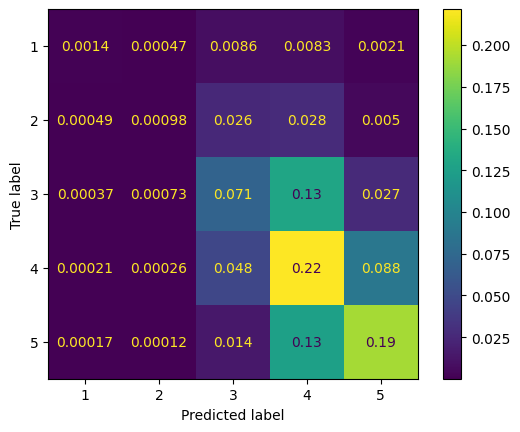

In [23]:
cm = confusion_matrix(test_y, predictions, labels=CB_model.classes_, normalize='all') 
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=CB_model.classes_) 
disp.plot()
plt.show()

In [24]:
precision_score(test_y, predictions, average='micro')


0.4864937220571306

## задание 3

In [25]:
book_descr = pd.read_csv('book_descr.csv')
book_descr

,book_id,descr,descr_vecs
0,1,"In a future North America, where the rulers of...",[ 0.11025178 -0.21036306 -0.02822943 0.266000...
1,2,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...
2,3,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...
3,4,Harper Lee's Pulitzer Prize-winning masterwork...,[ 2.73116946e-01 -1.85827732e-01 -1.73755307e-...
4,5,A young man newly rich tries to recapture the ...,[ 0.07466012 -0.37611896 -0.02056331 0.190791...
...,...,...,...
9995,9996,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...
9996,9997,"In Means of Ascent, Book Two of The Years of L...",[ 1.00363903e-01 -2.19032750e-01 -7.23591596e-...
9997,9998,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...
9998,9999,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...


In [26]:
# Обработаем пропущенные значения и типы данных в столбце 'descr'
book_descr['descr'] = book_descr['descr'].fillna('')
book_descr['descr'] = book_descr['descr'].astype(str)
book_descr

,book_id,descr,descr_vecs
0,1,"In a future North America, where the rulers of...",[ 0.11025178 -0.21036306 -0.02822943 0.266000...
1,2,,[-2.0151265 -0.5475724 -0.34907195 0.067971...
2,3,,[-2.0151265 -0.5475724 -0.34907195 0.067971...
3,4,Harper Lee's Pulitzer Prize-winning masterwork...,[ 2.73116946e-01 -1.85827732e-01 -1.73755307e-...
4,5,A young man newly rich tries to recapture the ...,[ 0.07466012 -0.37611896 -0.02056331 0.190791...
...,...,...,...
9995,9996,,[-2.0151265 -0.5475724 -0.34907195 0.067971...
9996,9997,"In Means of Ascent, Book Two of The Years of L...",[ 1.00363903e-01 -2.19032750e-01 -7.23591596e-...
9997,9998,,[-2.0151265 -0.5475724 -0.34907195 0.067971...
9998,9999,,[-2.0151265 -0.5475724 -0.34907195 0.067971...


In [27]:
describes = book_descr['descr'].apply(lambda x: x.split())

In [28]:
# Обучаем модель FastText
FastText_model = FastText(sentences=describes, vector_size=100, window=10, min_count=1) 


65811

In [29]:
# Получение векторных представлений для каждого предложения
descr_vecs = []
for title in book_descr['descr']:
    word_vecs = [FastText_model.wv[word] for word in title.split() if word in FastText_model.wv.key_to_index]  
    if word_vecs:
        descr_vecs.append(np.mean(word_vecs, axis=0))
    else:
        descr_vecs.append(np.zeros(FastText_model.wv.vector_size))
descr_vecs

[array([-0.6095671 ,  0.45820332, -1.1640896 , -0.03380251,  0.5863435 ,
         0.91153914,  0.48781508,  0.4291473 ,  0.25548357, -0.3823492 ,
         0.71957296,  0.22925577, -0.50961417,  1.2168545 , -0.734193  ,
        -0.43293178, -0.40806845,  0.16331689, -0.7708493 , -0.9659877 ,
        -0.90896845, -0.071835  , -0.11088506, -0.17312789, -0.930858  ,
        -0.8678705 , -0.82487875, -0.322138  ,  0.3979137 ,  0.4144647 ,
        -0.63267016,  0.19484416,  1.1019729 , -0.86813205, -0.11883166,
         0.7751227 ,  0.01443763,  1.0612009 ,  0.18828805, -0.22132094,
         1.2058787 , -1.0428702 ,  0.13308892, -0.40614703, -1.1585332 ,
        -0.931722  , -0.14094667,  0.5072998 ,  0.9172879 ,  0.47279975,
         0.2162611 , -0.7649025 ,  0.6047447 , -1.0373489 , -0.05712306,
        -0.48879188, -0.00831121,  0.10595082, -0.10616369, -0.1532155 ,
        -0.26174244, -0.197473  ,  0.02238025,  1.0913779 , -0.29127285,
         0.61332524,  0.04501858, -0.3769526 ,  0.4

In [35]:
book_vecs_df = pd.DataFrame(descr_vecs)
book_vecs_df.columns = [f'descr_vecs_feature_{i}' for i in range(fasttext_df.shape[1])]
# Добавим столбец 'book_id' в DataFrame
book_vecs_df['book_id'] = book_descr['book_id'].values
book_vecs_df

,descr_vecs_feature_0,descr_vecs_feature_1,descr_vecs_feature_2,descr_vecs_feature_3,descr_vecs_feature_4,descr_vecs_feature_5,descr_vecs_feature_6,descr_vecs_feature_7,descr_vecs_feature_8,descr_vecs_feature_9,descr_vecs_feature_10,descr_vecs_feature_11,descr_vecs_feature_12,descr_vecs_feature_13,descr_vecs_feature_14,descr_vecs_feature_15,descr_vecs_feature_16,descr_vecs_feature_17,descr_vecs_feature_18,descr_vecs_feature_19,descr_vecs_feature_20,descr_vecs_feature_21,descr_vecs_feature_22,descr_vecs_feature_23,descr_vecs_feature_24,descr_vecs_feature_25,descr_vecs_feature_26,descr_vecs_feature_27,descr_vecs_feature_28,descr_vecs_feature_29,descr_vecs_feature_30,descr_vecs_feature_31,descr_vecs_feature_32,descr_vecs_feature_33,descr_vecs_feature_34,descr_vecs_feature_35,descr_vecs_feature_36,descr_vecs_feature_37,descr_vecs_feature_38,descr_vecs_feature_39,descr_vecs_feature_40,descr_vecs_feature_41,descr_vecs_feature_42,descr_vecs_feature_43,descr_vecs_feature_44,descr_vecs_feature_45,descr_vecs_feature_46,descr_vecs_feature_47,descr_vecs_feature_48,descr_vecs_feature_49,...,descr_vecs_feature_51,descr_vecs_feature_52,descr_vecs_feature_53,descr_vecs_feature_54,descr_vecs_feature_55,descr_vecs_feature_56,descr_vecs_feature_57,descr_vecs_feature_58,descr_vecs_feature_59,descr_vecs_feature_60,descr_vecs_feature_61,descr_vecs_feature_62,descr_vecs_feature_63,descr_vecs_feature_64,descr_vecs_feature_65,descr_vecs_feature_66,descr_vecs_feature_67,descr_vecs_feature_68,descr_vecs_feature_69,descr_vecs_feature_70,descr_vecs_feature_71,descr_vecs_feature_72,descr_vecs_feature_73,descr_vecs_feature_74,descr_vecs_feature_75,descr_vecs_feature_76,descr_vecs_feature_77,descr_vecs_feature_78,descr_vecs_feature_79,descr_vecs_feature_80,descr_vecs_feature_81,descr_vecs_feature_82,descr_vecs_feature_83,descr_vecs_feature_84,descr_vecs_feature_85,descr_vecs_feature_86,descr_vecs_feature_87,descr_vecs_feature_88,descr_vecs_feature_89,descr_vecs_feature_90,descr_vecs_feature_91,descr_vecs_feature_92,descr_vecs_feature_93,descr_vecs_feature_94,descr_vecs_feature_95,descr_vecs_feature_96,descr_vecs_feature_97,descr_vecs_feature_98,descr_vecs_feature_99,book_id
0,-0.609567,0.458203,-1.164090,-0.033803,0.586344,0.911539,0.487815,0.429147,0.255484,-0.382349,0.719573,0.229256,-0.509614,1.216854,-0.734193,-0.432932,-0.408068,0.163317,-0.770849,-0.965988,-0.908968,-0.071835,-0.110885,-0.173128,-0.930858,-0.867871,-0.824879,-0.322138,0.397914,0.414465,-0.632670,0.194844,1.101973,-0.868132,-0.118832,0.775123,0.014438,1.061201,0.188288,-0.221321,1.205879,-1.042870,0.133089,-0.406147,-1.158533,-0.931722,-0.140947,0.507300,0.917288,0.472800,...,-0.764902,0.604745,-1.037349,-0.057123,-0.488792,-0.008311,0.105951,-0.106164,-0.153215,-0.261742,-0.197473,0.022380,1.091378,-0.291273,0.613325,0.045019,-0.376953,0.408676,0.686678,0.009678,0.330576,0.259819,-0.338369,0.346187,-0.239519,1.057562,0.502847,-0.878916,0.424558,-0.391980,-0.883001,-0.888479,-0.163781,-0.527074,-0.947641,1.329906,0.437827,-0.134934,-0.661969,-0.774851,0.384236,-0.077840,0.073855,-0.879955,0.727235,-0.308244,-0.647781,0.269533,0.179565,1
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000

In [31]:
books = pd.concat([books, book_vecs_df], axis=1)
books

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url,fasttext_feature_0,fasttext_feature_1,fasttext_feature_2,fasttext_feature_3,fasttext_feature_4,fasttext_feature_5,fasttext_feature_6,fasttext_feature_7,fasttext_feature_8,fasttext_feature_9,fasttext_feature_10,fasttext_feature_11,fasttext_feature_12,fasttext_feature_13,fasttext_feature_14,fasttext_feature_15,fasttext_feature_16,fasttext_feature_17,fasttext_feature_18,fasttext_feature_19,fasttext_feature_20,fasttext_feature_21,fasttext_feature_22,fasttext_feature_23,fasttext_feature_24,fasttext_feature_25,fasttext_feature_26,...,descr_vecs_feature_50,descr_vecs_feature_51,descr_vecs_feature_52,descr_vecs_feature_53,descr_vecs_feature_54,descr_vecs_feature_55,descr_vecs_feature_56,descr_vecs_feature_57,descr_vecs_feature_58,descr_vecs_feature_59,descr_vecs_feature_60,descr_vecs_feature_61,descr_vecs_feature_62,descr_vecs_feature_63,descr_vecs_feature_64,descr_vecs_feature_65,descr_vecs_feature_66,descr_vecs_feature_67,descr_vecs_feature_68,descr_vecs_feature_69,descr_vecs_feature_70,descr_vecs_feature_71,descr_vecs_feature_72,descr_vecs_feature_73,descr_vecs_feature_74,descr_vecs_feature_75,descr_vecs_feature_76,descr_vecs_feature_77,descr_vecs_feature_78,descr_vecs_feature_79,descr_vecs_feature_80,descr_vecs_feature_81,descr_vecs_feature_82,descr_vecs_feature_83,descr_vecs_feature_84,descr_vecs_feature_85,descr_vecs_feature_86,descr_vecs_feature_87,descr_vecs_feature_88,descr_vecs_feature_89,descr_vecs_feature_90,descr_vecs_feature_91,descr_vecs_feature_92,descr_vecs_feature_93,descr_vecs_feature_94,descr_vecs_feature_95,descr_vecs_feature_96,descr_vecs_feature_97,descr_vecs_feature_98,descr_vecs_feature_99
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,-0.921205,0.567225,-0.112519,0.961920,0.666393,0.112745,0.267845,0.216969,0.133343,-0.296061,-0.141519,0.564935,0.039483,0.454538,-0.206369,-0.553551,0.314547,-0.044614,0.015623,-0.393981,-0.080217,-0.248209,0.024001,0.209196,-0.817138,-0.932066,-0.730926,...,0.216261,-0.764902,0.604745,-1.037349,-0.057123,-0.488792,-0.008311,0.105951,-0.106164,-0.153215,-0.261742,-0.197473,0.022380,1.091378,-0.291273,0.613325,0.045019,-0.376953,0.408676,0.686678,0.009678,0.330576,0.259819,-0.338369,0.346187,-0.239519,1.057562,0.502847,-0.878916,0.424558,-0.391980,-0.883001,-0.888479,-0.163781,-0.527074,-0.947641,1.329906,0.437827,-0.134934,-0.661969,-0.774851,0.384236,-0.077840,0.073855,-0.879955,0.727235,-0.308244,-0.647781,0.269533,0.179565
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,-0.899307,0.553825,-0.109188,0.939756,0.652705,0.109247,0.258853,0.212251,0.130613,-0.287401,-0.138026,0.550051,0.039223,0.444300,-0.202186,-0.539316,0.304454,-0.042981,0.012921,-0.384640,-0.079710,-0.243714,0.023017,0.202310,-0.798604,-0.910234,-0.713153,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000

In [32]:
fasttext_word_vectors = fasttext_df.columns

In [37]:
#  Добавление признака в модель
train_df = train_df.merge(book_vecs_df, left_on='book_id', right_on='book_id', how='left')
test_df = test_df.merge(book_vecs_df, left_on='book_id', right_on='book_id', how='left')


In [42]:
# Повторное обучение модели и вычисление Precision
CB_model.fit(train_df.drop(columns=cols_to_drop), 
              train_y, 
              eval_set=(test_df.drop(columns=cols_to_drop), test_y),
              verbose=False,
              plot=True) 
predictions = CB_model.predict(test_df.drop(columns=cols_to_drop))

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Setting Precision metric value to the default 0
Number of the positive class predictions is 0. Set

In [43]:
precision_score(test_y, predictions, average='micro')

0.4823566714855567